In [82]:
from torch.utils.data import Dataset

class LinearOscillator2DDataset(Dataset):
    def __init__(self, num_batches, num_interior, num_terminal, T, x1_bounds=(-1., 1.), x2_bounds=(-1., 1.), tau_max=None, scale_to_minus1_1=True, scale_time_to_0_1=True):
        super().__init__()
        self.num_batches = num_batches
        self.num_interior = num_interior
        self.num_terminal = num_terminal
        self.T = float(T)
        self.x1_bounds = tuple(x1_bounds)
        self.x2_bounds = tuple(x2_bounds)
        self.tau_max = float(T if tau_max is None else tau_max)
        self.scale_to_minus1_1 = scale_to_minus1_1
        self.scale_time_to_0_1 = scale_time_to_0_1
        self.coordinate_dim = 2

    def __len__(self):
        return self.num_batches

    # sets the max time to sample from
    # picks the maximum time between 0 or the minimum of the full time and tau max
    def set_tau_max(self, tau_max):
        tau_max = float(tau_max)
        self.tau_max = max(0.0, min(self.T, tau_max))

    # sample n numbers uniformly in the range low to high
    def _sample_uniform(self, n, bounds):
        low, high = bounds
        return low + (high - low) * torch.rand(n, 1)

    # return n samples for each state in the range of their bounds
    def _sample_states_phys(self, n):
        x1 = self._sample_uniform(n, self.x1_bounds)
        x2 = self._sample_uniform(n, self.x2_bounds)
        return torch.cat([x1, x2], dim=-1)

    def _sample_tau_phys(self, n):
        if self.tau_max <= 0:
            return torch.zeros(n, 1)
        return self.tau_max * torch.rand(n, 1)

    # normalize tau to be between 0 and 1
    def _scale_tau(self, tau_phys):
        if not self.scale_time_to_0_1:
            return tau_phys
        return tau_phys / self.T

    def _scale_states(self, x_phys):
        if not self.scale_to_minus1_1:
            return x_phys
        bounds = torch.tensor([self.x1_bounds, self.x2_bounds], dtype=x_phys.dtype, device=x_phys.device)
        low = bounds[:, 0]
        high = bounds[:, 1]
        return 2.0 * (x_phys - low) / (high-low) - 1.0

    def __getitem__(self, idx):
        # sample interior points
        x_interior_phys = self._sample_states_phys(self.num_interior)
        x_interior_net = self._scale_states(x_interior_phys)
        tau_interior_phys = self._sample_tau_phys(self.num_interior)
        tau_interior_net = self._scale_tau(tau_interior_phys)
        xt_interior = torch.cat([x_interior_net, tau_interior_net], dim=-1)

        # sample terminal points
        x_terminal_phys = self._sample_states_phys(self.num_terminal)
        x_terminal_net = self._scale_states(x_terminal_phys)
        tau_terminal_phys = torch.zeros(self.num_terminal, 1)
        tau_terminal_net = self._scale_tau(tau_terminal_phys)
        xt_terminal = torch.cat([x_terminal_net, tau_terminal_net], dim=-1)

        return {
            "xt_interior": xt_interior.float(),
            "xt_terminal": xt_terminal.float(),
            "x_interior_phys": x_interior_phys.float(),
            "tau_interior_phys": tau_interior_phys.squeeze(-1).float(),
            "x_terminal_phys": x_terminal_phys.float()
        }

In [83]:
import torch
import torch.nn as nn

class LinearOscillator2DResidual(nn.Module):
    def __init__(self, oscillation_speed=1.0, control_bound=1.0, disturbance_bound=0.5, radius=0.25, T=1.0, x1_bounds=(-1.0, 1.0), x2_bounds=(-1.0, 1.0), scale_to_minus1_1=True, scale_time_to_01=True):
        super().__init__()
        self.oscillation_speed = float(oscillation_speed)
        self.control_bound = float(control_bound)
        self.disturbance_bound = float(disturbance_bound)
        self.radius = float(radius)
        self.T = float(T)
        self.x1_bounds = tuple(x1_bounds)
        self.x2_bounds = tuple(x2_bounds)
        self.scale_to_minus1_1 = scale_to_minus1_1
        self.scale_time_to_01 = scale_time_to_01

    # defines the target set as a circle 
    def target_function(self, x_phys):
        return torch.sqrt(x_phys[..., 0]**2 + x_phys[..., 1]**2 + 1e-12) - self.radius

    # unscale the coordinates
    def _unscale_x(self, x_net):
        if not self.scale_to_minus1_1:
            return x_net
        bounds = torch.tensor([self.x1_bounds, self.x2_bounds], dtype=x_net.dtype, device=x_net.device)
        low = bounds[:, 0]
        high = bounds[:, 1]
        return 0.5 * (x_net + 1.0) * (high - low) + low

    # unscales the spatial gradient of the network
    def _unscale_spatial_gradient(self, spatial_grad):
        if not self.scale_to_minus1_1:
            return spatial_grad
        bounds = torch.tensor([self.x1_bounds, self.x2_bounds], dtype=spatial_grad.dtype, device=spatial_grad.device)
        low = bounds[:, 0]
        high = bounds[:, 1]
        return spatial_grad * (2.0 / (high - low))

    # unscales the time derivative of the 
    def _unscale_time_gradient(self, time_grad):
        if not self.scale_time_to_01:
            return time_grad
        return time_grad / self.T

    # computes the hamiltonian 
    def compute_hamiltonian(self, x_phys, spatial_grad):
        x1 = x_phys[..., 0]
        x2 = x_phys[..., 1]
        partial_x1 = spatial_grad[..., 0]
        partial_x2 = spatial_grad[..., 1]

        base = partial_x1 * x2 + partial_x2 * (-(self.oscillation_speed**2) * x1)
        control_term = -self.control_bound * torch.abs(partial_x2)
        disturbance_term = self.disturbance_bound * torch.abs(partial_x2)
        
        return base + control_term + disturbance_term

    def compute_residual(self, model, V, xt, latent, dlatent):
        dV_dxt, dV_dalpha = torch.autograd.grad(V, [xt, latent], grad_outputs=torch.ones_like(V), retain_graph=True, create_graph=True)

        spatial_grad_net = dV_dxt[:, :2]
        tau_grad_net = (dV_dalpha * dlatent).sum(dim=-1)

        x_net = xt[:, :2]
        x_phys = self._unscale_x(x_net)
        spatial_grad_phys = self._unscale_spatial_gradient(spatial_grad_net)
        tau_grad_phys = self._unscale_time_gradient(tau_grad_net)

        level_set_x = self.target_function(x_phys)
        hamiltonian = self.compute_hamiltonian(x_phys, spatial_grad_phys)

        time_grad_phys = - tau_grad_phys
        V_scalar = V.squeeze(-1) if V.ndim > 1 else V

        residual = torch.minimum(time_grad_phys + hamiltonian, level_set_x - V_scalar)
        return residual

    def compute_loss(self, model, V, xt, latent, dlatent):
        residual = self.compute_residual(model, V, xt, latent, dlatent)
        loss_pinn = torch.mean(torch.abs(residual))
        return loss_pinn, residual

In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from torchdiffeq import odeint

class Swish(nn.Module):
    def __init__(self, beta=0.5):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor([beta]))

    def forward(self, x):
        return (x * torch.sigmoid_(x * F.softplus(self.beta))).div_(1.1)

# simple mlp
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, activation_fn=Swish, out_dim=None):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            activation_fn(),
            nn.Linear(hidden_dim, hidden_dim),
            activation_fn(),
            nn.Linear(hidden_dim, hidden_dim),
            activation_fn(),
            nn.Linear(hidden_dim, in_dim if out_dim is None else out_dim),
        ) 

    def forward(self, x):
        return self.model(x) 

# takes in current time and latent state 
# outputs the time derivative of latent state
class PNODE(nn.Module):
    def __init__(self, latent_dim, hidden_dim, activation_fn=Swish):
        super().__init__()
        self.model = MLP(in_dim=latent_dim+1, hidden_dim=hidden_dim, activation_fn=activation_fn, out_dim=latent_dim)

    def forward(self, t, latent_state):
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=latent_state.dtype, device=latent_state.device)
        if t.ndim == 0:
            t_expanded = t.expand(latent_state.shape[:-1] + (1,))
        else:
            t_expanded = t[..., None].expand(latent_state.shape[:-1] + (1,))
        inputs = torch.cat([latent_state, t_expanded], dim=-1)
        return self.model(inputs)


# takes in inputs and latent state alpha
# returns the learned linear projection of the inputs and latent state
class AdditiveConditioning(nn.Module):
    def __init__(self, inputs, latent_state, out):
        super().__init__()
        self.inputs = inputs
        self.latent_state = latent_state
        self.out = out
        self.A = nn.Parameter(torch.empty(self.out, self.latent_state))
        self.B = nn.Parameter(torch.empty(self.out, self.inputs))
        self.bias = nn.Parameter(torch.empty(self.out))
        self.reset_parameters()

    def reset_parameters(self):
        bound = 1 / math.sqrt(self.inputs)
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.B, a=math.sqrt(5))
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, inputs, latent_state):
        latent_state_transform = torch.einsum('...j,oj->...o', latent_state, self.A)
        inputs_transform = torch.einsum('...i,oi->...o', inputs, self.B)
        return latent_state_transform + inputs_transform + self.bias

# takes in spatial coordinates x and latent state alpha 
# multiplies enriched features of x with learned linear projections of previous output and alpha
class MFNBase(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim, out_dim, num_layers):
        super().__init__()
        self.conditioning = nn.ModuleList(
            [AdditiveConditioning(in_dim, latent_dim, hidden_dim)] + 
            [AdditiveConditioning(hidden_dim, latent_dim, hidden_dim) for _ in range(num_layers)]
        )
        self.conditioning_out = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, latent_state):
        out = self.filters[0](x) * self.conditioning[0](x * 0., latent_state)
        for i in range(1, len(self.filters)):
            out = self.filters[i](x) * self.conditioning[i](out, latent_state)
        out = self.conditioning_out(out)
        if out.shape[-1] == 1:
            out = out.squeeze(-1)
        return out

# takes in spatial coordinates x
# applies learned linear projections to them
# passes through sin and cos
# outputs enriched spatial features
class FourierLayer(nn.Module):
    def __init__(self, in_features, out_features, weight_scale):
        super().__init__()
        self.weight = nn.Parameter(torch.empty((out_features, in_features)))
        self.weight_scale = weight_scale
        self.reset_parameters()

    # initialize the parameters to kaiming uniform distirbution
    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

    def forward(self, x):
        return torch.cat([
            torch.sin(F. linear(x, self.weight * self.weight_scale)),
            torch.cos(F.linear(x, self.weight * self.weight_scale))
        ], dim=-1)


# takes in spatial coordinates x
# applies learned linear projections to them
# passes through sin
# outputs enriched spatial features
class SirenLayer(nn.Module):
    def __init__(self, in_features, out_features, omega0=30.0, is_first=False):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.omega0 = omega0
        self.is_first = is_first

        self.weight = nn.Parameter(torch.empty((out_features, in_features)))
        self.bias = nn.Parameter(torch.empty(out_features))
        self.reset_parameters()

    def reset_parameters(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / self.in_features
            else:
                bound = math.sqrt(6.0 / self.in_features) / self.omega0
            self.weight.uniform_(-bound, bound)
            self.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * F.linear(x, self.weight, self.bias))


# builds the filters for MFN
class FourierNet(MFNBase):
    def __init__(self, in_dim, hidden_dim, latent_dim, out_dim, num_layers=3, input_scale=256.0):
        super().__init__(in_dim, hidden_dim, latent_dim, out_dim, num_layers)
        self.filters = nn.ModuleList(
            [FourierLayer(in_dim, hidden_dim // 2, input_scale / np.sqrt(num_layers+1)) for _ in range(num_layers + 1)]
        )

# builds the filters for MFN
class SirenNet(MFNBase):
    def __init__(self, in_dim, hidden_dim, latent_dim, out_dim, num_layers=3, omega0=30.0):
        super().__init__(in_dim, hidden_dim, latent_dim, out_dim, num_layers)
        self.filters = nn.ModuleList([
            SirenLayer(in_dim, hidden_dim, omega0=omega0, is_first=(i==0)) for i in range(num_layers+1)
        ])

# takes in spatial coordinates x and latents alpha(tau)
# outputs the value function v(x, alpha(tau))
class Decoder(nn.Module):
    def __init__(self, hidden_dim, latent_dim, coordinate_dim, out_dim, num_layers, net_type="fourier", input_scale=64, omega0=30.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.coordinate_dim = coordinate_dim
        self.out_dim = out_dim
        if net_type == "fourier":
            self.model = FourierNet(in_dim=self.coordinate_dim, hidden_dim=self.hidden_dim, latent_dim=self.latent_dim, out_dim=self.out_dim, num_layers=num_layers, input_scale=input_scale)
        else:
            self.model = SirenNet(in_dim=self.coordinate_dim, hidden_dim=self.hidden_dim, latent_dim=self.latent_dim, out_dim=self.out_dim, num_layers=num_layers, omega0=omega0)
    
    def forward(self, x, latents):
        return self.model(x, latents)


class INR_PNODE(nn.Module):
    def __init__(self, latent_dim, decoder, pnode, loss_manager, ode_solver=odeint, method="dopri5", rtol=1e-7, atol=1e-9, device=None):
        super().__init__()
        self.latent_dim = latent_dim
        self.decoder = decoder
        self.pnode = pnode
        self.loss_manager = loss_manager
        self.ode_solver = ode_solver
        self.method = method
        self.rtol = rtol
        self.atol = atol
        self.device = device

        self.alpha0 = nn.Parameter(torch.zeros(1, self.latent_dim))

    # returns the latents and their time derivatives at each tau qeury
    def compute_latent_and_dlatent(self, tau_queries):
        tau_queries = tau_queries.reshape(-1)
        unique_taus, inverse_indices = torch.unique(tau_queries, sorted=True, return_inverse=True)

        if unique_taus.numel() == 0 or unique_taus[0].item() > 0.0:
            t_eval = torch.cat([torch.zeros(1, device=tau_queries.device, dtype=unique_taus.dtype), unique_taus], dim=0)
            prepend_zero = True
        else:
            t_eval = unique_taus
            prepend_zero = False

        latent_trajectory = self.ode_solver(self.pnode, self.alpha0, t_eval, rtol=self.rtol, atol=self.atol, method=self.method)[:, 0, :]
        dlatent_trajectory = torch.stack([self.pnode(t_eval[i], latent_trajectory[i:i+1]).squeeze(0) for i in range(t_eval.shape[0])], dim=0)

        if prepend_zero:
            unique_latents = latent_trajectory[1:]
            unique_dlatents = dlatent_trajectory[1:]
        else:
            unique_latents = latent_trajectory
            unique_dlatents = dlatent_trajectory

        latents = unique_latents[inverse_indices]
        dlatents = unique_dlatents[inverse_indices]

        return latents, dlatents

    def decode_terminal(self, xt_terminal):
        num_terminal = xt_terminal.shape[0]
        latent0 = self.alpha0.expand(num_terminal, self.latent_dim)
        x_terminal = xt_terminal[:, :self.decoder.coordinate_dim]
        return self.decoder(x_terminal, latent0)

    # computes the latents and dlatents at the time queries
    # passes the spatial coordinates and the latents into the decoder
    # to obtain the value at that coordinate and time 
    def compute_value_at_xt(self, xt, tau_phys):
        latent, dlatent = self.compute_latent_and_dlatent(tau_phys)
        latent = latent.requires_grad_(True)
        x = xt[:, :self.decoder.coordinate_dim]
        
        # compute value at x and latent(tau)
        V = self.decoder(x, latent)

        return V, latent, dlatent
    
    def compute_losses(self, batch, mode="train"):
        xt_interior = batch["xt_interior"].to(self.device).float().requires_grad_(True)
        tau_interior_phys = batch["tau_interior_phys"].to(self.device).float()
        xt_terminal = batch["xt_terminal"].to(self.device).float()
        x_terminal_phys = batch["x_terminal_phys"].to(self.device).float()
    
        V, latent, dlatent = self.compute_value_at_xt(xt_interior, tau_interior_phys)
    
        if mode == "visualization":
            return V.detach().cpu().numpy()
    
        V_terminal = self.decode_terminal(xt_terminal)
    
        loss_dict = self.loss_manager.compute_losses(model=self, xt_interior=xt_interior, x_terminal_phys=x_terminal_phys, V=V, V_terminal=V_terminal, latent=latent, dlatent=dlatent)
    
        loss_train = (self.loss_manager.loss_weights["terminal"] * loss_dict["loss_terminal"] + self.loss_manager.loss_weights["pinn"] * loss_dict["loss_pinn"])
        loss_dict["loss_train"] = loss_train
        return loss_dict

    def create_optimizers(self, lr=1e-4, ode_lr=None):
        if ode_lr is None:
            ode_lr = lr/10

        return {
            "optim_decoder": torch.optim.Adam(self.decoder.parameters(), lr=lr),
            "optim_ode": torch.optim.Adam(self.pnode.parameters(), lr=ode_lr),
            "optim_alpha0": torch.optim.Adam([self.alpha0], lr=lr),
        }

In [85]:
import torch.nn as nn

class LossManager():
    def __init__(self, residual, loss_weights=None):
        self.residual = residual
        self.loss_weights = {"terminal": 1.0, "pinn": 1.0} if loss_weights is None else loss_weights
        self.criterion = nn.MSELoss()
        
    def compute_losses(self, model, xt_interior, x_terminal_phys, V, V_terminal, latent, dlatent):
        target_level_set = self.residual.target_function(x_terminal_phys)
    
        loss_terminal = self.criterion(V_terminal, target_level_set)
        loss_pinn, _ = self.residual.compute_loss(
            model=model,
            V=V,
            xt=xt_interior,
            latent=latent,
            dlatent=dlatent,
        )
    
        return {
            "loss_terminal": loss_terminal,
            "loss_pinn": loss_pinn,
        }

In [90]:
import argparse
from torch.utils.data import DataLoader

args = argparse.Namespace(
    lr=1e-3,
    device=device,
)

# problem dimensions
args.coord_dim = 2
args.code_dim = 128
args.latent_dim = args.code_dim

# model size
args.hidden_c = 128
args.hidden_c_enc = 32
args.n_layers = 3
args.input_scale = 16.0

# ODE solver
args.method = "dopri5"
args.rtol = 1e-7
args.atol = 1e-9

# linear oscillator params
args.T = 1.0
args.omega = 1.0
args.u_bound = 1.0
args.d_bound = 0.5
args.beta = 0.25

# domain
args.x1_bounds = (-1.0, 1.0)
args.x2_bounds = (-1.0, 1.0)

# training batch sampling
args.num_batches = 1000
args.num_interior = 4096
args.num_terminal = 4096

# scaling
args.scale_to_minus1_1 = False
args.scale_time_to_01 = True


dataset_tr = LinearOscillator2DDataset(
    num_batches=args.num_batches,
    num_interior=args.num_interior,
    num_terminal=args.num_terminal,
    T=args.T,
    x1_bounds=args.x1_bounds,
    x2_bounds=args.x2_bounds,
    tau_max=0.0,   # terminal pretraining
    scale_to_minus1_1=args.scale_to_minus1_1,
    scale_time_to_0_1=args.scale_time_to_01,
)

dataloader_tr = DataLoader(
    dataset_tr,
    batch_size=None,
    shuffle=False,
)


residual = LinearOscillator2DResidual(
    oscillation_speed=args.omega,
    control_bound=args.u_bound,
    disturbance_bound=args.d_bound,
    radius=args.beta,
    T=args.T,
    x1_bounds=args.x1_bounds,
    x2_bounds=args.x2_bounds,
    scale_to_minus1_1=args.scale_to_minus1_1,
    scale_time_to_01=args.scale_time_to_01,
)

loss_manager = LossManager(
    residual=residual,
    loss_weights={"terminal": 1.0, "pinn": 1.0},
)

decoder = Decoder(
    hidden_dim=args.hidden_c_enc,
    latent_dim=args.code_dim,
    coordinate_dim=args.coord_dim,
    out_dim=1,
    num_layers=args.n_layers,
    net_type="fourier",   # or "siren"
    input_scale=args.input_scale,
)

pnode = PNODE(
    latent_dim=args.code_dim,
    hidden_dim=args.hidden_c,
    activation_fn=Swish,   # or nn.Tanh()
)

model = INR_PNODE(
    latent_dim=args.code_dim,
    decoder=decoder,
    pnode=pnode,
    loss_manager=loss_manager,
    ode_solver=odeint,
    method=args.method,
    rtol=args.rtol,
    atol=args.atol,
    device=args.device,
).to(device)

optimizers = model.create_optimizers(lr=args.lr)

print(f"Decoder params:  {sum(p.numel() for p in model.decoder.parameters()):,}")
print(f"Dynamics params: {sum(p.numel() for p in model.pnode.parameters()):,}")
print(f"alpha0 shape:    {tuple(model.alpha0.shape)}")

Decoder params:  19,809
Dynamics params: 66,179
alpha0 shape:    (1, 128)


In [91]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

@torch.no_grad()
def plot_linear_oscillator(
    model,
    device,
    tau,
    x1_bounds=(-1.0, 1.0),
    x2_bounds=(-1.0, 1.0),
    nx=201,
    chunk_size=4096,
    scale_to_minus1_1=False,
    T=1.0,
    scale_time_to_01=True,
    threshold=0.25,
    show_terminal_target=True,
    title=None,
    show_heatmap=True,
    save_path=None,   # e.g. "linear_oscillator_tau_0.50.png"
    dpi=300,
):
    model_was_training = model.training
    model.eval()

    x1 = np.linspace(x1_bounds[0], x1_bounds[1], nx)
    x2 = np.linspace(x2_bounds[0], x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    pts_phys = np.stack([X1.reshape(-1), X2.reshape(-1)], axis=-1).astype(np.float32)

    pts_net = pts_phys.copy()
    if scale_to_minus1_1:
        lo = np.array([x1_bounds[0], x2_bounds[0]], dtype=np.float32)
        hi = np.array([x1_bounds[1], x2_bounds[1]], dtype=np.float32)
        pts_net = 2.0 * (pts_net - lo) / (hi - lo) - 1.0

    tau_net = tau / T if scale_time_to_01 else tau
    tau_col = np.full((pts_net.shape[0], 1), tau_net, dtype=np.float32)
    xt_np = np.concatenate([pts_net, tau_col], axis=-1)

    vals = []
    for start in range(0, xt_np.shape[0], chunk_size):
        end = min(start + chunk_size, xt_np.shape[0])

        xt_chunk = torch.tensor(xt_np[start:end], dtype=torch.float32, device=device)
        tau_phys_chunk = torch.full(
            (end - start,),
            float(tau),
            dtype=torch.float32,
            device=device,
        )
        
        V_chunk, _, _ = model.compute_value_at_xt(xt_chunk, tau_phys_chunk)

        if isinstance(V_chunk, tuple):
            V_chunk = V_chunk[0]

        vals.append(V_chunk.reshape(-1).detach().cpu().numpy())

    V = np.concatenate(vals, axis=0).reshape(nx, nx)

    plt.figure(figsize=(7, 6))

    if show_heatmap:
        cf = plt.contourf(X1, X2, V, levels=40)
        plt.colorbar(cf, label="V(x, tau)")

    # learned zero level set
    plt.contour(
        X1, X2, V,
        levels=[0.0],
        colors="red",
        linewidths=2.5,
        linestyles="-",
    )

    # true terminal target
    if show_terminal_target:
        th = np.linspace(0, 2 * np.pi, 400)
        r = threshold
        plt.plot(
            r * np.cos(th),
            r * np.sin(th),
            color="black",
            linestyle="--",
            linewidth=2.0,
        )

    handles = [Line2D([0], [0], color="red", lw=2.5, linestyle="-", label="learned V=0")]
    if show_terminal_target:
        handles.append(Line2D([0], [0], color="black", lw=2.0, linestyle="--", label="true terminal target"))
    plt.legend(handles=handles)

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.xlim(x1_bounds)
    plt.ylim(x2_bounds)
    plt.gca().set_aspect("equal")

    if title is None:
        title = f"Linear Oscillator Boundary at tau={tau:.2f}"
    plt.title(title)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    if save_path is None:
        save_path = f"linear_oscillator_2_tau_{tau:.2f}.png"
    plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
    
    plt.show()

    if model_was_training:
        model.train()

0 0.2058590054512024 0.2058590054512024
50 0.003900995012372732 0.003900995012372732
100 0.0005870955064892769 0.0005870955064892769
150 0.00028505592490546405 0.00028505592490546405
200 0.00015682546654716134 0.00015682546654716134
250 0.00011328313848935068 0.00011328313848935068
300 7.325431215576828e-05 7.325431215576828e-05
350 5.7624281907919794e-05 5.7624281907919794e-05
400 5.2759129175683483e-05 5.2759129175683483e-05
450 3.403433947823942e-05 3.403433947823942e-05
500 3.097928856732324e-05 3.097928856732324e-05
550 2.7537389541976154e-05 2.7537389541976154e-05
600 2.3979922843864188e-05 2.3979922843864188e-05
650 2.0048722944920883e-05 2.0048722944920883e-05
700 1.8366405129199848e-05 1.8366405129199848e-05
750 1.6053136278060265e-05 1.6053136278060265e-05
800 1.591698128322605e-05 1.591698128322605e-05
850 1.2420223356457427e-05 1.2420223356457427e-05
900 1.3407118785835337e-05 1.3407118785835337e-05
950 1.2036618500133045e-05 1.2036618500133045e-05


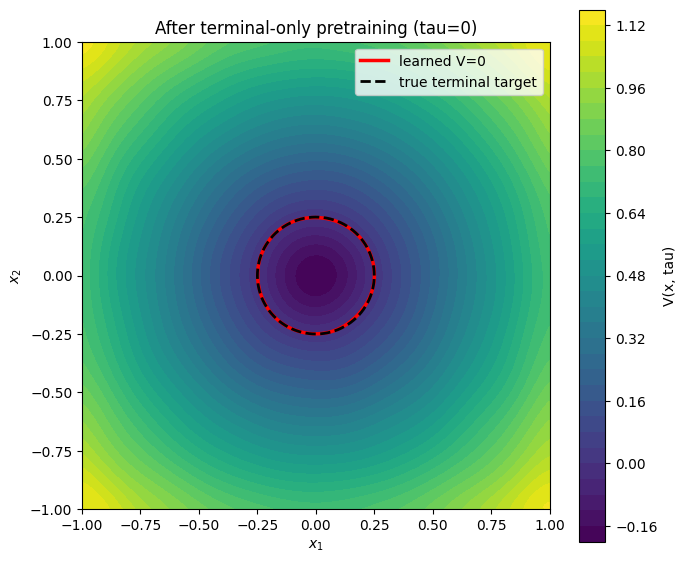

In [92]:
dataset_tr.set_tau_max(0.0)
model.loss_manager.loss_weights = {"terminal": 1.0, "pinn": 0.0}

for step, batch in enumerate(dataloader_tr):
    if step >= 2000:
        break

    for opt in optimizers.values():
        opt.zero_grad()

    results = model.compute_losses(batch, mode="train")
    results["loss_train"].backward()

    torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(model.pnode.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_([model.alpha0], max_norm=1.0)

    for opt in optimizers.values():
        opt.step()

    if step % 50 == 0:
        print(
            step,
            results["loss_terminal"].item(),
            results["loss_train"].item(),
        )

plot_linear_oscillator(
    model,
    device=device,
    tau=0.0,
    x1_bounds=args.x1_bounds,
    x2_bounds=args.x2_bounds,
    nx=201,
    chunk_size=4096,
    scale_to_minus1_1=args.scale_to_minus1_1,
    T=args.T,
    scale_time_to_01=args.scale_time_to_01,
    threshold=args.beta,
    show_terminal_target=True,
    title="After terminal-only pretraining (tau=0)",
)


Training with tau_max = 0.05
step    0 | loss=2.976e-01 | term=1.179e-05 | pinn=2.975e-01
step   50 | loss=9.931e-03 | term=2.832e-04 | pinn=9.648e-03
step  100 | loss=6.510e-03 | term=1.080e-04 | pinn=6.402e-03
step  150 | loss=5.418e-03 | term=1.019e-04 | pinn=5.316e-03
step  200 | loss=5.369e-03 | term=9.009e-05 | pinn=5.279e-03
step  250 | loss=5.077e-03 | term=1.002e-04 | pinn=4.977e-03
step  300 | loss=4.811e-03 | term=1.070e-04 | pinn=4.704e-03
step  350 | loss=4.582e-03 | term=8.317e-05 | pinn=4.498e-03
step  400 | loss=4.595e-03 | term=9.084e-05 | pinn=4.504e-03
step  450 | loss=4.562e-03 | term=7.997e-05 | pinn=4.482e-03


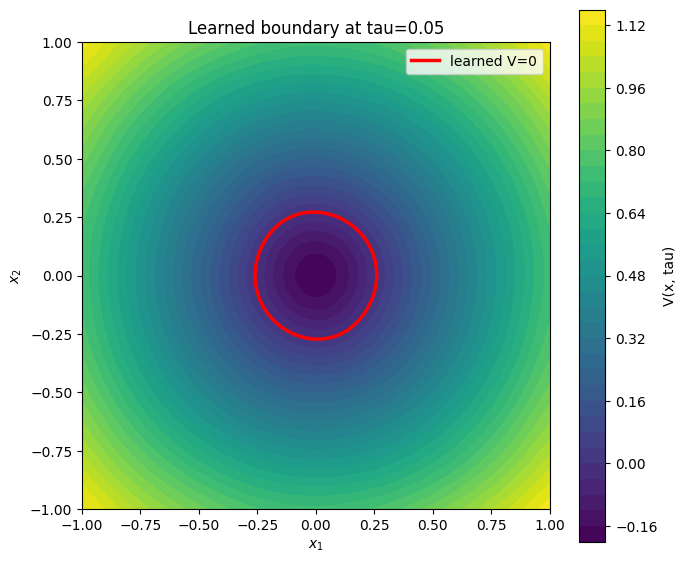


Training with tau_max = 0.10
step    0 | loss=8.482e-03 | term=6.966e-05 | pinn=8.412e-03


In [ ]:
tau_schedule = [0.05, 0.1, 0.2, 0.4, 0.7, 1.0]
steps_per_stage = 500

model.loss_manager.loss_weights = {"terminal": 1.0, "pinn": 1.0}

for tau_max in tau_schedule:
    dataset_tr.set_tau_max(tau_max)
    print(f"\nTraining with tau_max = {tau_max:.2f}")

    for step, batch in enumerate(dataloader_tr):
        if step >= steps_per_stage:
            break

        for opt in optimizers.values():
            opt.zero_grad()

        results = model.compute_losses(batch, mode="train")
        results["loss_train"].backward()

        torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model.pnode.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_([model.alpha0], max_norm=1.0)

        for opt in optimizers.values():
            opt.step()

        if step % 50 == 0:
            print(
                f"step {step:4d} | "
                f"loss={results['loss_train'].item():.3e} | "
                f"term={results['loss_terminal'].item():.3e} | "
                f"pinn={results['loss_pinn'].item():.3e}"
            )

    plot_linear_oscillator(
        model,
        device=device,
        tau=tau_max,
        x1_bounds=args.x1_bounds,
        x2_bounds=args.x2_bounds,
        nx=201,
        chunk_size=4096,
        scale_to_minus1_1=args.scale_to_minus1_1,
        T=args.T,
        scale_time_to_01=args.scale_time_to_01,
        threshold=args.beta,
        show_terminal_target=(tau_max == 0.0),
        title=f"Learned boundary at tau={tau_max:.2f}",
    )